In [1]:
# PACKAGES
## data manipulation
import pandas as pd
import numpy as np

## confidence interval
import math

# ANOVA
import scipy.stats as stats

## data viz
import seaborn as sns
import matplotlib.pyplot as plt

## linear and polynominal regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

## cluster analysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# PATHS AND METHODS

## My min max scaler
def my_scaler(x_unscaled, x_min=None, x_max=None):
    if x_min == None:
        x_min=x_unscaled.min()
    if x_max == None:
        x_max=x_unscaled.max()
    x_scaled = (x_unscaled - x_min)/(x_max - x_min)
    return x_scaled

## confidence interval 95%
def my_ci_95(stats, r=2):
    
    ci95_hi = []
    ci95_lo = []
    alpha = []

    for i in stats.index:
        m, c, s = stats.loc[i]
        a = 1.96*s/math.sqrt(c)
        ci95_hi.append(m + a)
        ci95_lo.append(m - a)
        alpha.append(a)

    stats['ci95_lo'] = ci95_lo
    stats['ci95_hi'] = ci95_hi
    stats['alpha'] = alpha

    stats['mean'] = round(stats['mean'], r)
    stats['alpha'] = round(stats['alpha'], r)

    return(stats.reset_index())

In [3]:
# DEFINING EXPERIMENT PARAMETERS
## seed list
seed_list = [428956419, 1954324947, 1145661099, 1835732737, 794161987, 1329531353, 200496737, 633816299, 1410143363, 1282538739, 1029384756, 564738291, 918273645, 675849302, 123456789, 987654321, 246813579, 135792468, 1123581321, 314159265, 271828182, 161803398, 141421356, 173205080, 223606797, 707106781, 866025403, 577215664, 299792458, 602214076]

## scenarion list
scenario_list = ['2ec_low_on', '2ec_low_off', '2ec_high_on', '2ec_high_off']
#scenario_list = ['2ec_high_off']

## algorithms list
#algo_list = ['tetris', 'thea', 'argos', 'faticanti']
algo_list = ['tetris', 'thea']

In [4]:
# IMPORT DATASETS

# dataframes
total_seed_server = pd.DataFrame()
total_seed_user = pd.DataFrame()
total_seed_service = pd.DataFrame()
# object to count the quantity of experiments
n_exp = 0

# loop to get results
for algo_name in algo_list:

    for scenario in scenario_list:

        ## count experiment
        n_exp = n_exp + 1

        for seed_value in seed_list:

            # server
            ## getting results by seeds
            each_seed_server = pd.read_csv(f"results/{algo_name}_logsserver_{scenario}_{seed_value}.csv")
            each_seed_server['seed'] = seed_value
            each_seed_server['scenario'] = scenario
            each_seed_server['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_server = pd.concat([total_seed_server, each_seed_server])
            total_seed_server = total_seed_server.reset_index(drop=True)

            # user
            ## getting results by seeds
            each_seed_user = pd.read_csv(f"results/{algo_name}_logsuser_{scenario}_{seed_value}.csv")
            each_seed_user['seed'] = seed_value
            each_seed_user['scenario'] = scenario
            each_seed_user['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_user = pd.concat([total_seed_user, each_seed_user])
            total_seed_user = total_seed_user.reset_index(drop=True)

            # service
            ## getting results by seeds
            each_seed_service = pd.read_csv(f"results/{algo_name}_logsservice_{scenario}_{seed_value}.csv")
            each_seed_service['seed'] = seed_value
            each_seed_service['scenario'] = scenario
            each_seed_service['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_service = pd.concat([total_seed_service, each_seed_service])
            total_seed_service = total_seed_service.reset_index(drop=True)

In [5]:
# FEATURE ENGINEERING

## create new obj to do feature engineering
dt_power = total_seed_server.loc[(total_seed_server['Available'])].reset_index(drop=True).copy()
dt_server = total_seed_server.loc[(total_seed_server['Available']) & (total_seed_server['CPU Demand'] > 0)].reset_index(drop=True).copy()
dt_user = total_seed_user.copy()
dt_service = total_seed_service.copy()

## alogrithm + scenario column
dt_power['algorithm_scenario'] = dt_power['algorithm'] + '_' + dt_server['scenario']
dt_server['algorithm_scenario'] = dt_server['algorithm'] + '_' + dt_server['scenario']
dt_user['algorithm_scenario'] = dt_user['algorithm'] + '_' + dt_user['scenario']
dt_service['algorithm_scenario'] = dt_service['algorithm'] + '_' + dt_service['scenario']

## Infra
dt_power['cloud'] = dt_power['scenario'].str.split('_', expand=True)[2]
dt_server['cloud'] = dt_server['scenario'].str.split('_', expand=True)[2]
dt_user['cloud'] = dt_user['scenario'].str.split('_', expand=True)[2]
dt_service['cloud'] = dt_service['scenario'].str.split('_', expand=True)[2]

## user dataset
# compute sla violation variable
dt_user['sla_violations'] = 0
dt_user.loc[dt_user['Delay sla deadlines'] < 0, 'sla_violations'] = 1
dt_user['cumulative_sla_violations'] = dt_user.groupby(['algorithm', 'scenario', 'seed'])['sla_violations'].cumsum()

# compute drops
dt_user_drop = dt_user.groupby(by=['algorithm', 'scenario', 'Object','seed'])['Delays'].agg(['last']).reset_index().rename(columns={'last':'Delays'})
dt_user_drop['drop'] = 0
dt_user_drop.loc[dt_user_drop['Delays'].isna(), 'drop'] = 1
## infra
dt_user_drop['cloud'] = dt_user_drop['scenario'].str.split('_', expand=True)[2]

## server dataset
# compute server access
dt_server['server_access'] = 0
dt_server.loc[dt_server['CPU Demand'] > 0, 'server_access'] = 1
dt_server['cumulative_server_access'] = dt_server.groupby(['Instance ID', 'algorithm', 'scenario', 'seed'])['server_access'].cumsum()
dt_total_server_access = dt_server.groupby(['algorithm', 'scenario', 'seed'])['server_access'].sum().reset_index().rename(columns={'server_access':'total_server_access'})
dt_server = dt_server.merge(dt_total_server_access, how='left', on=['algorithm', 'scenario', 'seed'])
dt_total_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['total_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_total_server_access_avg['product'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['count']
dt_total_server_access_avg = dt_total_server_access_avg.merge(dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_total_server_access_avg['weight'] = dt_total_server_access_avg['product']/dt_total_server_access_avg['sum']
dt_total_server_access_avg['n_server_access'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['weight']
dt_total_server_access_avg = dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['n_server_access'].agg(['sum']).reset_index().rename(columns={'sum':'n_server_access'})
dt_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['cumulative_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_server_access_avg['product'] = dt_server_access_avg['mean']*dt_server_access_avg['count']
dt_server_access_avg = dt_server_access_avg.merge(dt_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['weight'] = dt_server_access_avg['product']/dt_server_access_avg['sum']
dt_server_access_avg = dt_server_access_avg.merge(dt_total_server_access_avg, how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['server_access_by_server'] = dt_server_access_avg['n_server_access']*dt_server_access_avg['weight']
## infra
dt_server_access_avg['cloud'] = dt_server_access_avg['scenario'].str.split('_', expand=True)[2]


# compute free resources
dt_server['CPU Free'] = dt_server['CPU'] - dt_server['CPU Demand']
dt_server['RAM Free'] = dt_server['RAM'] - dt_server['RAM Demand']
# compute usage metrics
dt_server['CPU Usage'] = (dt_server['CPU Demand'] * 100) / dt_server['CPU']
dt_server['RAM Usage'] = (dt_server['RAM Demand'] * 100) / dt_server['RAM']
dt_server['Servers Usage'] = (dt_server['CPU Usage'] + dt_server['RAM Usage']) / 2

# create new obj withou cloud server
dt_server_edge = dt_server.loc[(dt_server['Instance ID'] != 7)].reset_index(drop=True)

# normalization
## Imbalance
dt_server_edge_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['CPU Free']].apply(my_scaler).reset_index().rename(columns={'CPU Free':'CPU Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_cpu[['CPU Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['RAM Free']].apply(my_scaler).reset_index().rename(columns={'RAM Free':'RAM Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_ram[['RAM Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
## Fragmentation
dt_server_edge_rf_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_cpu']].apply(my_scaler).reset_index().rename(columns={'rf_cpu':'rf_cpu_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_cpu[['rf_cpu_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_rf_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_memory']].apply(my_scaler).reset_index().rename(columns={'rf_memory':'rf_memory_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_ram[['rf_memory_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')

# compute Resource Imbalance Index (RII)
dt_server_edge['RII'] = dt_server_edge[['CPU Free_norm', 'RAM Free_norm']].std(axis=1)
# compute Resource Fragmentation Index (RFI)
dt_server_edge['RFI'] = dt_server_edge[['rf_cpu_norm', 'rf_memory_norm']].mean(axis=1)

In [6]:
# pre processing

## RFI x SLA
dt_server_rfi = dt_server_edge.groupby(by=['algorithm', 'scenario', 'seed'])['RFI'].mean().reset_index()
dt_user_sla = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['cumulative_sla_violations'].max().reset_index()
dt_user_drop_mean = dt_user_drop.groupby(by=['algorithm', 'scenario', 'seed'])['drop'].sum().reset_index()
dt_user_delay = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['Delays'].mean().reset_index()
dt_power_mean = dt_power.groupby(by=['algorithm', 'scenario', 'seed'])['Power Consumption'].mean().reset_index()
# merges
dt_rfi_sla = dt_server_rfi.merge(dt_user_sla, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay = dt_rfi_sla.merge(dt_user_delay, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay_power = dt_rfi_sla_delay.merge(dt_power_mean, how='left', on=['algorithm', 'scenario', 'seed'])
dt_rfi_sla_delay_power_drop = dt_rfi_sla_delay_power.merge(dt_user_drop_mean, how='left', on=['algorithm', 'scenario', 'seed'])
## infra
dt_rfi_sla_delay_power_drop['cloud'] = dt_rfi_sla_delay_power_drop['scenario'].str.split('_', expand=True)[2]
dt_rfi_sla_delay_power_drop['workload'] = dt_rfi_sla_delay_power_drop['scenario'].str.split('_', expand=True)[1]
dt_rfi_sla_delay_power_drop.to_csv('final_dataset.csv', index=False)

In [7]:
metric_columns = ['RFI', 'cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop']
dt_metric = dt_rfi_sla_delay_power_drop[metric_columns]
dt_metric['drop'].value_counts()

drop
0    210
2     21
1      9
Name: count, dtype: int64

In [8]:
print('total - pearson correlation:')
display(dt_metric.corr())
print('total - spearman correlation:')
display(dt_metric.corr(method='spearman'))

total - pearson correlation:


,RFI,cumulative_sla_violations,Delays,Power Consumption,drop
RFI,1.000000,0.570748,-0.029124,0.297860,0.535961
cumulative_sla_violations,0.570748,1.000000,-0.207791,0.219126,0.888585
Delays,-0.029124,-0.207791,1.000000,-0.164044,-0.234411
Power Consumption,0.297860,0.219126,-0.164044,1.000000,0.073148
drop,0.535961,0.888585,-0.234411,0.073148,1.000000


total - spearman correlation:


,RFI,cumulative_sla_violations,Delays,Power Consumption,drop
RFI,1.000000,0.487486,-0.330643,0.327026,0.518859
cumulative_sla_violations,0.487486,1.000000,0.118846,0.307720,0.570712
Delays,-0.330643,0.118846,1.000000,-0.133901,-0.159665
Power Consumption,0.327026,0.307720,-0.133901,1.000000,0.131302
drop,0.518859,0.570712,-0.159665,0.131302,1.000000


In [9]:
print('total - pearson correlation:')
display(dt_metric.corr()[['RFI']])
print('total - spearman correlation:')
display(dt_metric.corr(method='spearman')[['RFI']])

total - pearson correlation:


,RFI
RFI,1.000000
cumulative_sla_violations,0.570748
Delays,-0.029124
Power Consumption,0.297860
drop,0.535961


total - spearman correlation:


,RFI
RFI,1.000000
cumulative_sla_violations,0.487486
Delays,-0.330643
Power Consumption,0.327026
drop,0.518859


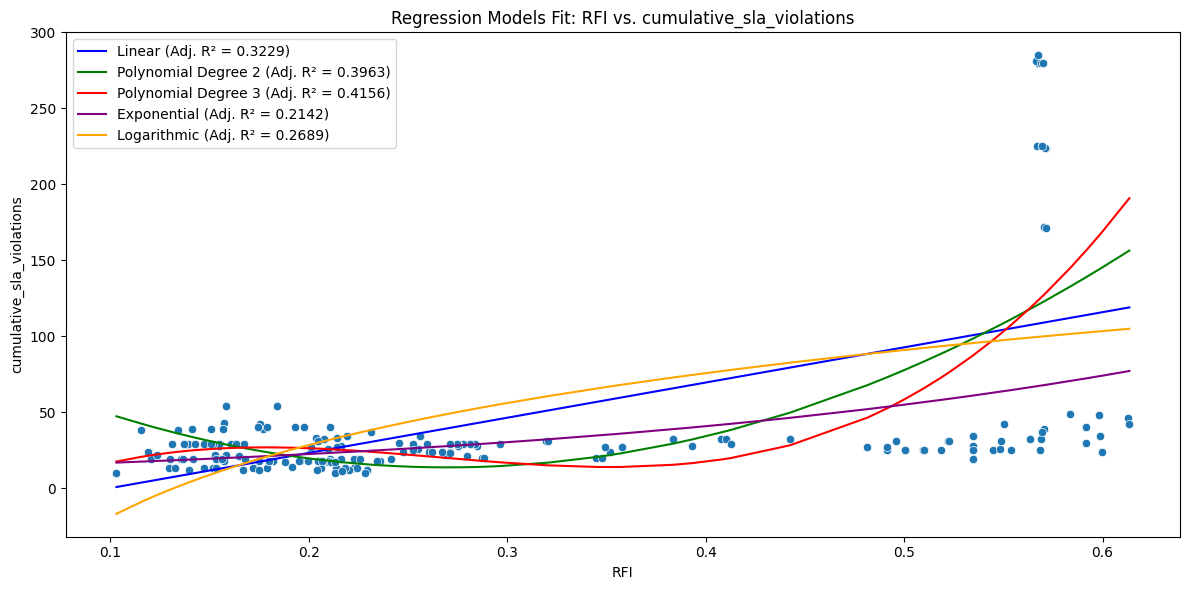

In [10]:
# Carregar o dataset
df = dt_metric  # ou substitua por seu DataFrame já carregado

# Definir variáveis genéricas
x_var = "RFI"
y_var = "cumulative_sla_violations"
#hue_var = dt_rfi_sla_delay_power_drop['algorithm']
hue_var = None
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Modelos de regressão
models = {}

# Linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
models["Linear"] = (y_lin, adjusted_r2(r2_score(y, y_lin), len(y), 1))

# Polinomial grau 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)
poly2_reg = LinearRegression().fit(X_poly2, y)
y_poly2 = poly2_reg.predict(X_poly2)
models["Polynomial Degree 2"] = (y_poly2, adjusted_r2(r2_score(y, y_poly2), len(y), 2))

# Polinomial grau 3
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)
poly3_reg = LinearRegression().fit(X_poly3, y)
y_poly3 = poly3_reg.predict(X_poly3)
models["Polynomial Degree 3"] = (y_poly3, adjusted_r2(r2_score(y, y_poly3), len(y), 3))

# Exponencial
log_y = np.log(y + 1e-9)
exp_reg = LinearRegression().fit(X, log_y)
y_exp = np.exp(exp_reg.predict(X))
models["Exponential"] = (y_exp, adjusted_r2(r2_score(y, y_exp), len(y), 2))

# Logarítmico
X_log = np.log(X + 1e-9)
log_reg = LinearRegression().fit(X_log, y)
y_log = log_reg.predict(X_log)
models["Logarithmic"] = (y_log, adjusted_r2(r2_score(y, y_log), len(y), 2))

# Plot com seaborn
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df[x_var], y=df[y_var], hue=hue_var)

colors = {
    "Linear": "blue",
    "Polynomial Degree 2": "green",
    "Polynomial Degree 3": "red",
    "Exponential": "purple",
    "Logarithmic": "orange"
}

for name, (y_pred, adj_r2) in models.items():
    sns.lineplot(x=df[x_var], y=y_pred, label=f"{name} (Adj. R² = {adj_r2:.4f})", color=colors[name])

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
#plt.savefig(f"{x_var}_vs_{y_var}_all_models.png")
plt.show()


In [11]:
# Carregar o dataset
df = dt_metric

# Selecionar colunas relevantes para clustering
features = ["cumulative_sla_violations", "Delays", "Power Consumption", "RFI"]
#features = ["cumulative_sla_violations", "RFI"]
X = df[features].dropna()

# Normalizar os dados
X_first_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)

## Definindo a quantidade de componentes
n = len(features)
## Objeto contendo as informações do modelo
rules = PCA(n_components=n)
## Criando o nome das colunas
cols = []
for i in range(1, (rules.n_components + 1)):
    cols.append('PC' + str(i))
    
## Reduzindo dimensionalidade com PCA
pca_dt = pd.DataFrame(rules.fit_transform(X_first_scaled).round(4), columns=cols, index=X_first_scaled.index)

## Coeficientes de cada componente do modelo
pca_coef = pd.DataFrame(rules.components_.T, columns=cols, index=X_first_scaled.columns)
## Variância explicada pelo modelo
### Transformando em dataframe
pca_explicada = pd.DataFrame(rules.explained_variance_ratio_*100).reset_index()
### Renomeando
pca_explicada.columns = ['PC', 'Explicada_%']
### Corrigindo valor para componentes
pca_explicada['PC'] = range(1, (rules.n_components + 1))
### Adicionando variável para armazenar variância acumulada
pca_explicada['Cum_Explicada_%'] = pca_explicada['Explicada_%'].cumsum()
display(pca_explicada.head(2))
display(pca_coef[['PC1', 'PC2']])

,PC,Explicada_%,Cum_Explicada_%
0,1,45.267160,45.267160
1,2,24.750416,70.017576


,PC1,PC2
cumulative_sla_violations,0.610873,0.137914
Delays,-0.267247,0.888396
Power Consumption,0.440157,-0.190613
RFI,0.601395,0.394206


c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

elbow k 2 inertia 638.9961875310098
elbow k 3 inertia 400.74452311277247
elbow k 4 inertia 260.0717544855713
elbow k 5 inertia 130.82738914389245
elbow k 6 inertia 77.3404303819813
elbow k 7 inertia 62.24580919452559
elbow k 8 inertia 44.63271110132601
elbow k 9 inertia 29.878576128260946
elbow k 10 inertia 26.3282947990019


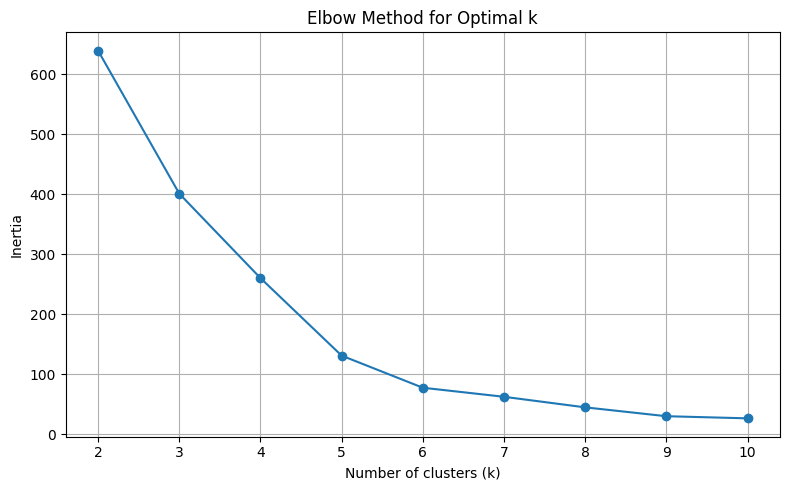

c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\c

silhouette k 2 score 0.47736158363275233
silhouette k 3 score 0.49373634575560565
silhouette k 4 score 0.5491024031522138
silhouette k 5 score 0.60193412600594
silhouette k 6 score 0.6909709941407485
silhouette k 7 score 0.6979854632661376
silhouette k 8 score 0.6886946566772513
silhouette k 9 score 0.7047725308003386
silhouette k 10 score 0.7005744742232444


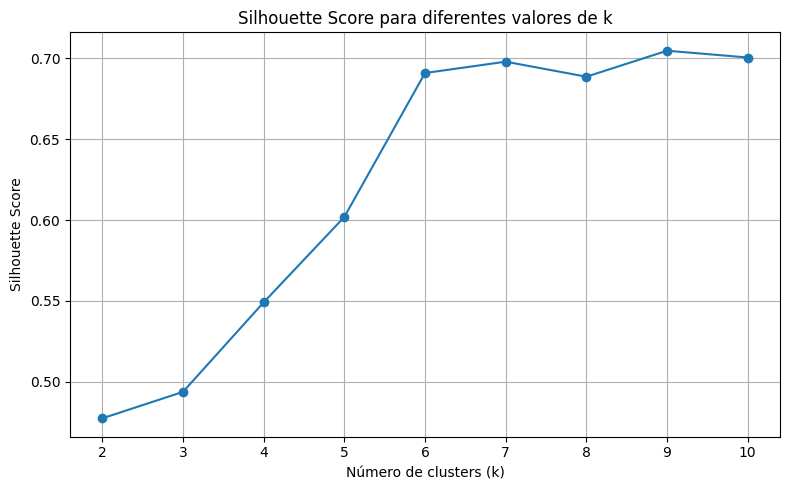

In [12]:
#x_kmeans = pca_dt.loc[:, ['PC1', 'PC2']]
random_number = seed_list[6]
x_kmeans = X_first_scaled

# Elbow method to determine optimal number of clusters
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_number)
    kmeans.fit(x_kmeans)
    inertia.append(kmeans.inertia_)
    print('elbow k', k, 'inertia', kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular Silhouette Score para diferentes valores de k
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_number)
    labels = kmeans.fit_predict(x_kmeans)
    score = silhouette_score(x_kmeans, labels)
    silhouette_scores.append(score)
    print('silhouette k', k, 'score', score)

# Plotar o gráfico
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes valores de k')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\LucasMascarenhas\miniconda3\envs\phd\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


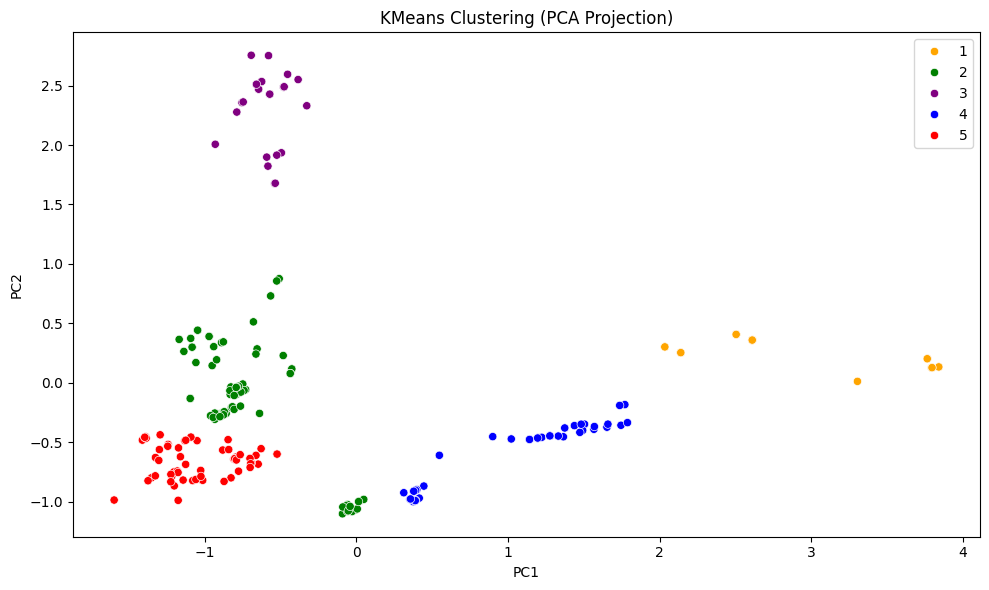

Número de elementos por cluster:
cluster
2    76
5    60
4    44
1    30
3    30
Name: count, dtype: int64


In [13]:
# Aplicar KMeans
kmeans = KMeans(n_clusters=5, random_state=random_number)
clusters = kmeans.fit_predict(x_kmeans)

# manipulations to convert from the original cluster output to final paper plot
clusters[clusters == 4] = 10
clusters[clusters == 2] = 20
clusters[clusters == 1] = 30
clusters[clusters == 0] = 40
clusters[clusters == 3] = 50

clusters = (clusters/10).astype(int)

dt_rfi_sla_delay_power_drop['cluster'] = clusters
pca_dt['cluster'] = clusters

# Plotar os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_dt.iloc[:, 0], y=pca_dt.iloc[:, 1], hue=clusters, palette=['orange', 'green', 'purple', 'blue', 'red'])
plt.title("KMeans Clustering (PCA Projection)")
plt.tight_layout()
plt.savefig("kmeans_clusters_pca_to_paper.png")
plt.show()


# Exibir número de elementos por cluster
print("Número de elementos por cluster:")
print(dt_rfi_sla_delay_power_drop["cluster"].value_counts())
dt_rfi_sla_delay_power_drop["cluster"] = dt_rfi_sla_delay_power_drop["cluster"].astype(str)
dt_rfi_sla_delay_power_drop["algo_load_cloud"] = dt_rfi_sla_delay_power_drop["algorithm"] + "_" + dt_rfi_sla_delay_power_drop["workload"] + "_" + dt_rfi_sla_delay_power_drop["cloud"]
# coordinates values to plot on overleaf
pca_dt.loc[:, ['PC1', 'PC2', 'cluster']].to_csv('list_of_coordinates.csv', index=False)

In [14]:
dt_rfi_sla_delay_power_drop.groupby(by='cluster')[features].agg(['count', 'mean', 'std', 'min', 'max']).T

cluster                                   1           2           3  \
cumulative_sla_violations count   30.000000   76.000000   30.000000   
                          mean   227.266667   26.986842   28.000000   
                          std     39.569174   11.498978    3.667189   
                          min    171.000000   12.000000   20.000000   
                          max    285.000000   54.000000   32.000000   
Delays                    count   30.000000   76.000000   30.000000   
                          mean    29.815755   71.712296  152.708371   
                          std      1.088112   23.276462    7.090843   
                          min     27.857143   30.000000  145.161290   
                          max     31.714286  117.666667  177.187500   
Power Consumption         count   30.000000   76.000000   30.000000   
                          mean   194.910240  194.457570  180.169339   
                          std     11.397011    7.505536    9.459783   
                          min    185.543864  175.387039  171.426714   
                          max    212.079439  204.348265  200.069258   
RFI                       count   30.000000   76.000000   30.000000   
                          mean     0.569849    0.173866    0.454788   
                          std      0.001454    0.035678    0.076119   
                          min      0.566627    0.115760    0.319567   
                          max      0.571479    0.247603    0.548571   

cluster                                   4           5  
cumulative_sla_violations count   44.000000   60.000000  
                          mean    30.522727   20.716667  
                          std      7.299215    6.974753  
                          min     19.000000   10.000000  
                          max     49.000000   34.000000  
Delays                    count   44.000000   60.000000  
                          mean    26.436407   29.599407  
                          std      3.628680    6.476193  
                          min     22.500000   22.222222  
                          max     32.758621   40.000000  
Power Consumption         count   44.000000   60.000000  
                          mean   206.654041  170.437888  
                          std      2.670354    3.802642  
                          min    196.046262  165.417934  
                          max    209.643919  179.255035  
RFI                       count   44.000000   60.000000  
                          mean     0.467016    0.209952  
                          std      0.133189    0.037759  
                          min      0.270991    0.103183  
                          max      0.613469    0.271012

In [15]:
display(dt_rfi_sla_delay_power_drop.groupby(by='cluster')[['cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop', 'RFI']].corr()[['RFI']].reset_index())
display(dt_rfi_sla_delay_power_drop.groupby(by='cluster')[['cumulative_sla_violations', 'Delays', 'Power Consumption', 'drop', 'RFI']].corr(method='spearman')[['RFI']].reset_index())

,cluster,level_1,RFI
0,1,cumulative_sla_violations,-0.732911
1,1,Delays,0.431045
2,1,Power Consumption,-0.770685
3,1,drop,0.824219
4,1,RFI,1.000000
5,2,cumulative_sla_violations,-0.159670
6,2,Delays,-0.463556
7,2,Power Consumption,0.554771
8,2,drop,NaN
9,2,RFI,1.000000


,cluster,level_1,RFI
0,1,cumulative_sla_violations,-0.872514
1,1,Delays,0.039651
2,1,Power Consumption,-0.360309
3,1,drop,0.751730
4,1,RFI,1.000000
5,2,cumulative_sla_violations,-0.041577
6,2,Delays,-0.158696
7,2,Power Consumption,0.571976
8,2,drop,NaN
9,2,RFI,1.000000


In [16]:
dt_rfi_sla_delay_power_drop.groupby(by='cluster')['algo_load_cloud'].value_counts()

cluster  algo_load_cloud
1        thea_high_off      30
2        tetris_high_on     30
         thea_low_on        30
         tetris_high_off    16
3        thea_high_on       30
4        thea_low_off       30
         tetris_high_off    14
5        tetris_low_off     30
         tetris_low_on      30
Name: count, dtype: int64

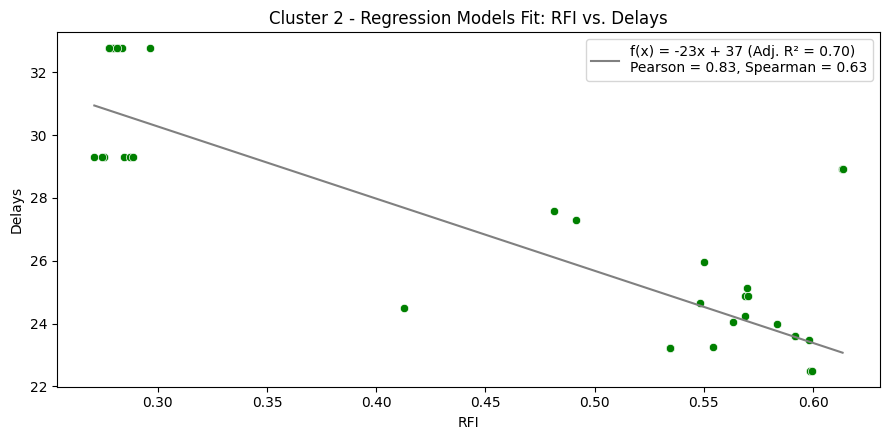

In [17]:
# Filtrar o DataFrame para o cluster 2
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '4']

# Definir variáveis
x_var = "RFI"
y_var = "Delays"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='green')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.83, Spearman = 0.63", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster2_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 2 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster2_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

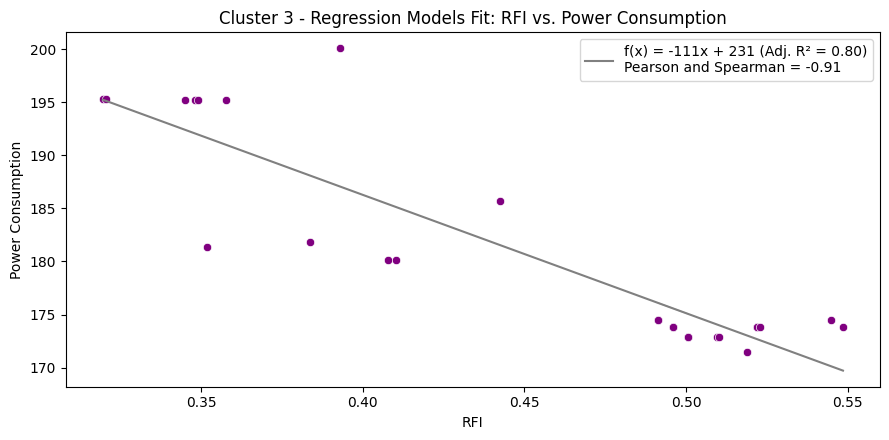

In [18]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '3']

# Definir variáveis
x_var = "RFI"
y_var = "Power Consumption"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='purple')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson and Spearman = -0.91", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster3_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 3 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster3_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

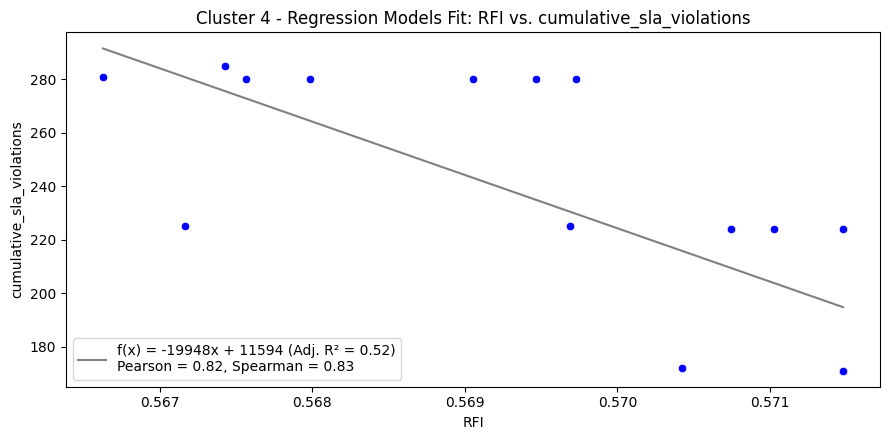

In [19]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '1']

# Definir variáveis
x_var = "RFI"
y_var = "cumulative_sla_violations"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='blue')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.82, Spearman = 0.83", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster4_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 4 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster4_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()

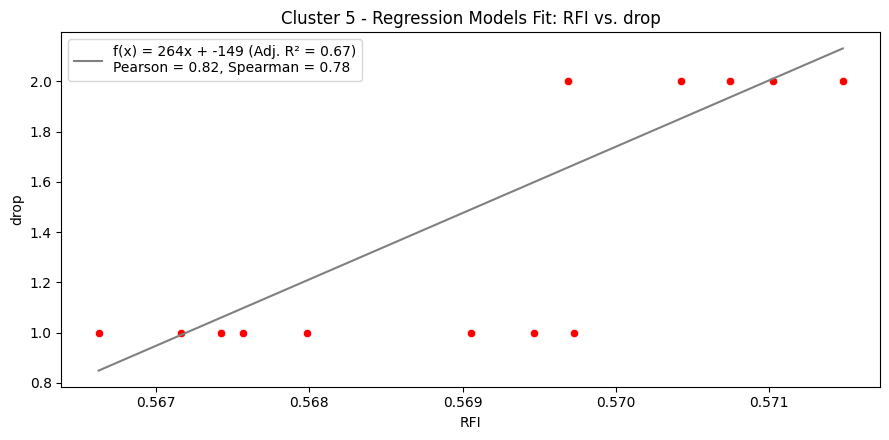

In [20]:
# Filtrar o DataFrame para o cluster 3
df = dt_rfi_sla_delay_power_drop.loc[dt_rfi_sla_delay_power_drop['cluster'] == '1']

# Definir variáveis
x_var = "RFI"
y_var = "drop"
X = df[x_var].values.reshape(-1, 1)
y = df[y_var].values

# Função para calcular R² ajustado
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Regressão linear
lin_reg = LinearRegression().fit(X, y)
y_lin = lin_reg.predict(X)
adj_r2 = adjusted_r2(r2_score(y, y_lin), len(y), 1)

# Coeficientes da equação
a = lin_reg.coef_[0]
b = lin_reg.intercept_
equation_text = f"f(x) = {a:.0f}x + {b:.0f}"

# Plot
plt.figure(figsize=(9, 4.5))
sns.scatterplot(x=df[x_var], y=df[y_var], color='red')
sns.lineplot(x=df[x_var], y=y_lin, label=f"{equation_text} (Adj. R² = {adj_r2:.2f})\nPearson = 0.82, Spearman = 0.78", color='gray')

# save to send to overleaf
df[[x_var, y_var]].reset_index(drop=True).to_csv(f"cluster5_{x_var}_vs_{y_var}_data.csv", index=False)

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Cluster 5 - Regression Models Fit: {x_var} vs. {y_var}")
plt.legend()
plt.tight_layout()
plt.savefig(f"cluster5_{x_var}_vs_{y_var}_linear_model_with_equation.png")
plt.show()